<a href="https://colab.research.google.com/github/anphucharry-dev/AI-15-ques/blob/main/HW_AI_13_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import folium

CENTER_LOC = [10.7756, 106.6920]
m = folium.Map(location=CENTER_LOC, zoom_start=15)

folium.Marker(
    CENTER_LOC,
    popup="UEH - Đại học Kinh tế TP.HCM",
    tooltip="Trung tâm",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(m)

locations = [
    {"name": "Bệnh viện Chợ Rẫy", "loc": [10.758001585566326, 106.65957744232013], "group": "Bệnh viện", "color": "blue"},
    {"name": "Vạn Hạnh Mall", "loc": [10.770806665543038, 106.66992279544849], "group": "Trung tâm thương mại", "color": "green"},
    {"name": "UBND Phường Hòa Hưng", "loc": [10.780758999945869, 106.66437826846423], "group": "Hành chính", "color": "purple"},
    {"name": "Công viên Lê Thị Riêng", "loc": [10.785337497054414, 106.66481306846433], "group": "Công viên", "color": "lightgreen"},
    {"name": "Trạm xe buýt Bến Thành", "loc": [10.7720, 106.6980], "group": "Giao thông", "color": "orange"}
]

layers = {}

for item in locations:
    group_name = item["group"]

    if group_name not in layers:
        layers[group_name] = folium.FeatureGroup(name=group_name).add_to(m)

    folium.Marker(
        location=item["loc"],
        popup=item["name"],
        tooltip=item["name"],
        icon=folium.Icon(color=item["color"])
    ).add_to(layers[group_name])

folium.LayerControl().add_to(m)
m

In [ ]:
import folium, time
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="ueh_ai_project", timeout=10)
center_location = geolocator.geocode("UEH University Ho Chi Minh City")
center = (center_location.latitude, center_location.longitude)

places = [
    "Bitexco Financial Tower Ho Chi Minh City",
    "Landmark 81 Ho Chi Minh City",
    "Saigon Zoo and Botanical Gardens Ho Chi Minh City",
    "Binh Tay Market Ho Chi Minh City",
    "Ho Chi Minh City Museum of Fine Arts",
    "Vinh Nghiem Pagoda Ho Chi Minh City",
    "Ba Chieu Market Ho Chi Minh City",
    "Thong Nhat Stadium Ho Chi Minh City",
    "Le Van Tam Park Ho Chi Minh City",
    "Turtle Lake Ho Chi Minh City"
]

m = folium.Map(location=center, zoom_start=13)
folium.Marker(center, popup="UEH", icon=folium.Icon(color="red")).add_to(m)

for place in places:
    try:
        loc = geolocator.geocode(place)
        time.sleep(1)
        point = (loc.latitude, loc.longitude)
        dist = geodesic(center, point).km


        folium.Marker(
            point,
            popup=f"Cách kho: {dist:.1f} km",
            tooltip=place,
            icon=folium.Icon(color="blue")
        ).add_to(m)


        folium.PolyLine([center, point], color="green", weight=2).add_to(m)

    except:
        print("Lỗi:", place)

m

In [ ]:
import folium
import random
from folium.plugins import HeatMap

ueh_coord = [10.7756, 106.6920]
m = folium.Map(location=ueh_coord, zoom_start=15)

distributions = [(50, 0.005), (20, 0.003), (10, 0.007)]
orders_data = []

for count, spread in distributions:
    for _ in range(count):
        lat = ueh_coord[0] + random.uniform(-spread, spread)
        lon = ueh_coord[1] + random.uniform(-spread, spread)
        orders_data.append([lat, lon])

HeatMap(orders_data, radius=18, blur=15).add_to(m)

folium.Marker(
    location=ueh_coord,
    popup="UEH",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(m)

m

In [ ]:
import folium

hcm_center = [10.7900, 106.6800]
m = folium.Map(location=hcm_center, zoom_start=12)

branches = [
    {"name": "Chi nhánh Tân Bình", "coords": [10.8015, 106.6526], "customers": 1200},
    {"name": "Chi nhánh Quận 7", "coords": [10.7339, 106.7215], "customers": 850},
    {"name": "Chi nhánh Gò Vấp", "coords": [10.8279, 106.6730], "customers": 950},
    {"name": "Chi nhánh Quận 10", "coords": [10.7743, 106.6669], "customers": 500},
    {"name": "Chi nhánh Thủ Đức", "coords": [10.8494, 106.7537], "customers": 1100}
]

for branch in branches:
    if branch["customers"] >= 1000:
        zone_color = "red"
    elif branch["customers"] >= 800:
        zone_color = "orange"
    else:
        zone_color = "green"

    folium.Circle(
        location=branch["coords"],
        radius=branch["customers"] * 2,
        color=zone_color,
        fill=True,
        fill_opacity=0.5,
        popup=f'{branch["name"]}<br>Khách hàng: {branch["customers"]}'
    ).add_to(m)

m

In [ ]:
import folium
from geopy.distance import geodesic

store_location = (10.7946, 106.7223)

destinations = [
    ("Đơn hàng A", (10.8000, 106.7200)),
    ("Đơn hàng B", (10.7850, 106.7150)),
    ("Đơn hàng C", (10.7950, 106.7500)),
    ("Đơn hàng D", (10.7600, 106.6900)),
    ("Đơn hàng E", (10.8200, 106.7000))
]

delivery_map = folium.Map(location=store_location, zoom_start=13)

folium.Marker(
    store_location,
    popup="Cửa hàng trung tâm",
    icon=folium.Icon(color="red", icon="home")
).add_to(delivery_map)

folium.Circle(
    store_location,
    radius=5000,
    color="blue",
    fill=True,
    fill_opacity=0.2,
    popup="Bán kính phục vụ 5km"
).add_to(delivery_map)

for order_id, coords in destinations:
    dist_km = geodesic(store_location, coords).km

    if dist_km <= 5.0:
        marker_color = "blue"
        status_text = "Hỗ trợ giao hàng"
    else:
        marker_color = "gray"
        status_text = "Nằm ngoài phạm vi"

    folium.Marker(
        coords,
        popup=f"{order_id}<br>Khoảng cách: {dist_km:.1f}km<br>{status_text}",
        icon=folium.Icon(color=marker_color)
    ).add_to(delivery_map)

delivery_map

In [ ]:
!pip install folium geopy osmnx networks

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.0 MB/s eta 0:00:00
  Created wheel for networks: filename=networks-0.3.7-py3-none-any.whl size=11636 sha256=b242c96c1b1246fe966700754f49c25bc892b521f37e965bf1b73c75401c84a6
  Stored in directory: /root/.cache/pip/wheels/02/16/46/19c90aaf8ff0dc26f9aa2e3a39b08b6a7302bf4de62ef5497d
Successfully built networks


Khu vực: District 4, Ho Chi Minh City, Vietnam
Số lượng nút giao: 412
Số lượng tuyến đường: 918
Tổng chiều dài: 49063.90 m
Chiều dài trung bình mỗi tuyến: 86.69 m


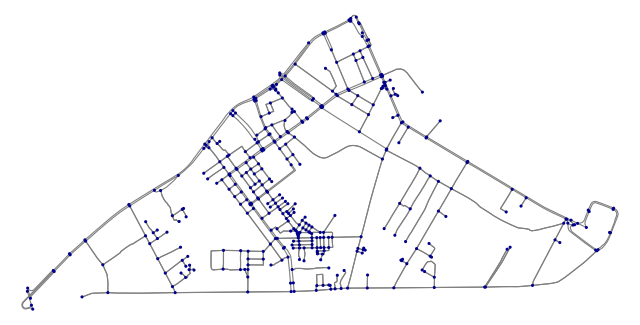

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

target_area = "District 4, Ho Chi Minh City, Vietnam"
road_network = ox.graph_from_place(target_area, network_type='drive')

analysis_results = ox.basic_stats(road_network)

print(f"Khu vực: {target_area}")
print(f"Số lượng nút giao: {analysis_results.get('n', 0)}")
print(f"Số lượng tuyến đường: {analysis_results.get('m', 0)}")
print(f"Tổng chiều dài: {analysis_results.get('street_length_total', 0):.2f} m")
print(f"Chiều dài trung bình mỗi tuyến: {analysis_results.get('street_length_avg', 0):.2f} m")

fig, ax = ox.plot_graph(
    road_network,
    bgcolor="white",
    node_color="darkblue",
    node_size=5,
    edge_color="gray",
    edge_linewidth=0.8
)


In [ ]:
import osmnx as ox
import networkx as nx
import folium
place="District 1, Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type="drive")
start_point=(10.7769,106.7009)
end_point=(10.7725,106.6980)
start_node=ox.distance.nearest_nodes(G,start_point[1],start_point[0])
end_node=ox.distance.nearest_nodes(G,end_point[1],end_point[0])
route_dijkstra=nx.shortest_path(G,start_node,end_node,weight="length",method="dijkstra")
route_astar=nx.astar_path(G,start_node,end_node,heuristic=lambda a,b:((G.nodes[a]["y"]-G.nodes[b]["y"])**2+(G.nodes[a]["x"]-G.nodes[b]["x"])**2)**0.5,weight="length")
dist_dijkstra=nx.path_weight(G,route_dijkstra,weight="length")
dist_astar=nx.path_weight(G,route_astar,weight="length")
print("Dijkstra distance (m):",round(dist_dijkstra,2))
print("A Star distance (m):",round(dist_astar,2))
print("Dijkstra nodes:",len(route_dijkstra))
print("A Star nodes:",len(route_astar))
m=folium.Map(location=start_point,zoom_start=15)
folium.Marker(location=start_point,popup="Start",icon=folium.Icon(color="green")).add_to(m)
folium.Marker(location=end_point,popup="End",icon=folium.Icon(color="red")).add_to(m)
coords_dijkstra=[(G.nodes[n]["y"],G.nodes[n]["x"]) for n in route_dijkstra]
coords_astar=[(G.nodes[n]["y"],G.nodes[n]["x"]) for n in route_astar]
folium.PolyLine(coords_dijkstra,color="blue",weight=5,popup="Dijkstra").add_to(m)
folium.PolyLine(coords_astar,color="orange",weight=3,popup="A Star").add_to(m)
m


Dijkstra distance (m): 796.4
A Star distance (m): 796.4
Dijkstra nodes: 9
A Star nodes: 9


In [ ]:
import pandas as pd
import folium
from scipy.spatial import distance_matrix
from scipy.optimize import linear_sum_assignment

q7_center = [10.7320, 106.7220]
dispatch_map = folium.Map(location=q7_center, zoom_start=14)

clients_df = pd.DataFrame({
    "lat": [10.7310, 10.7350, 10.7280, 10.7400],
    "lon": [106.7210, 106.7250, 106.7180, 106.7100]
})

vehicles_df = pd.DataFrame({
    "lat": [10.7300, 10.7380, 10.7250, 10.7420],
    "lon": [106.7220, 106.7200, 106.7150, 106.7050]
})

cost_matrix = distance_matrix(clients_df.values, vehicles_df.values)
client_indices, vehicle_indices = linear_sum_assignment(cost_matrix)

for c_idx, v_idx in zip(client_indices, vehicle_indices):
    c_loc = clients_df.iloc[c_idx].tolist()
    v_loc = vehicles_df.iloc[v_idx].tolist()

    folium.Marker(
        c_loc,
        icon=folium.Icon(color='purple', icon='user')
    ).add_to(dispatch_map)

    folium.Marker(
        v_loc,
        icon=folium.Icon(color='orange', icon='car')
    ).add_to(dispatch_map)

    folium.PolyLine(
        [c_loc, v_loc],
        color='blue',
        weight=3,
        dash_array='8, 8',
        tooltip=f"Khoảng cách: {cost_matrix[c_idx, v_idx]:.4f}"
    ).add_to(dispatch_map)

dispatch_map

In [ ]:
import folium
import random
import pandas as pd
center=(10.7756,106.6920)
data=[]
for i in range(35):
    lat=10.7756+random.uniform(-0.03,0.03)
    lon=106.6920+random.uniform(-0.03,0.03)
    speed=random.randint(10,60)
    volume=random.randint(80,300)
    risk=(60-speed)*0.7+volume*0.1
    data.append([lat,lon,speed,volume,risk])
df=pd.DataFrame(data,columns=["lat","lon","speed","volume","risk"])
m=folium.Map(location=center,zoom_start=13)
for i in range(len(df)):
    r=df.loc[i,"risk"]
    if r>=35: color="red"
    elif r>=20: color="orange"
    else: color="green"
    folium.CircleMarker(location=(df.loc[i,"lat"],df.loc[i,"lon"]),radius=7,color=color,fill=True,fill_opacity=0.8,popup="Risk "+str(round(r,1))).add_to(m)
old_route=[(10.7600,106.6800),(10.7700,106.6880),(10.7800,106.6960),(10.7900,106.7050)]
new_route=[(10.7600,106.6800),(10.7680,106.6840),(10.7760,106.6900),(10.7850,106.7000)]
folium.PolyLine(old_route,color="red",weight=5,popup="Congested Route").add_to(m)
folium.PolyLine(new_route,color="blue",weight=5,popup="Alternative Route").add_to(m)
m


In [ ]:
import folium
import random
import pandas as pd
from sklearn.linear_model import LinearRegression

map_center = (10.7320, 106.7220)
history_data = []

for _ in range(150):
    area_code = random.randint(1, 5)
    time_hour = random.randint(0, 23)
    lat_val = 10.7320 + random.uniform(-0.04, 0.04)
    lon_val = 106.7220 + random.uniform(-0.04, 0.04)
    total_demand = 20 + area_code * 10 + time_hour * 2 + random.randint(-8, 8)
    history_data.append([area_code, time_hour, lat_val, lon_val, total_demand])

df_records = pd.DataFrame(history_data, columns=["area_code", "time_hour", "lat", "lon", "total_demand"])
X_train = df_records[["area_code", "time_hour"]]
y_train = df_records["total_demand"]

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

future_predictions = []
target_hour = 19

for ac in range(1, 6):
    predicted_val = model_lr.predict([[ac, target_hour]])[0]
    p_lat = 10.7320 + random.uniform(-0.03, 0.03)
    p_lon = 106.7220 + random.uniform(-0.03, 0.03)
    future_predictions.append([ac, p_lat, p_lon, predicted_val])

demand_map = folium.Map(location=map_center, zoom_start=13)

for item in future_predictions:
    if item[3] >= 90:
        marker_color = "red"
    elif item[3] >= 70:
        marker_color = "orange"
    else:
        marker_color = "green"

    folium.CircleMarker(
        location=(item[1], item[2]),
        radius=9,
        color=marker_color,
        fill=True,
        fill_opacity=0.75,
        popup="Khu vuc "+str(item[0])+" | Nhu cau: "+str(round(item[3], 1))
    ).add_to(demand_map)

print(f"Du bao nhu cau luc {target_hour}h:")
for item in future_predictions:
    print("Khu vuc", item[0], ":", round(item[3], 1))

demand_map

Du bao nhu cau luc 19h:
Khu vuc 1 : 67.1
Khu vuc 2 : 77.4
Khu vuc 3 : 87.7
Khu vuc 4 : 98.0
Khu vuc 5 : 108.3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import folium
import random
from geopy.distance import geodesic

center=(10.7756,106.6920)

warehouses={
    "Kho A":(10.7756,106.6920),
    "Kho B":(10.7900,106.7100)
}

customers=[(10.7756+random.uniform(-0.03,0.03),106.6920+random.uniform(-0.03,0.03)) for i in range(10)]

routes={"Kho A":[],"Kho B":[]}

for customer in customers:
    best=min(warehouses,key=lambda w:geodesic(customer,warehouses[w]).km)
    routes[best].append(customer)

def route_distance(start,points):
    total=0
    current=start
    remain=points[:]
    while remain:
        nxt=min(remain,key=lambda p:geodesic(current,p).km)
        total+=geodesic(current,nxt).km
        current=nxt
        remain.remove(nxt)
    total+=geodesic(current,start).km
    return total

normal=0
best=0

for name in warehouses:
    start=warehouses[name]
    pts=routes[name]
    if len(pts)>0:
        normal+=sum(geodesic(start,p).km for p in pts)*2
        best+=route_distance(start,pts)

print("Tong km khong toi uu:",round(normal,2))
print("Tong km toi uu:",round(best,2))
print("Tiet kiem:",round(normal-best,2))

m=folium.Map(location=center,zoom_start=13)

for name,loc in warehouses.items():
    folium.Marker(location=loc,popup=name,icon=folium.Icon(color="red")).add_to(m)

colors=["blue","green"]

for i,name in enumerate(routes):
    start=warehouses[name]
    remain=routes[name][:]
    current=start
    path=[start]
    while remain:
        nxt=min(remain,key=lambda p:geodesic(current,p).km)
        path.append(nxt)
        current=nxt
        remain.remove(nxt)
    path.append(start)
    for p in routes[name]:
        folium.CircleMarker(location=p,radius=5,color=colors[i],fill=True,fill_opacity=0.8).add_to(m)
    folium.PolyLine(path,color=colors[i],weight=4,popup=name).add_to(m)

m


Tong km khong toi uu: 37.27
Tong km toi uu: 20.16
Tiet kiem: 17.11


In [ ]:
import folium
import random

hcm_east_center = (10.7950, 106.7220)
dashboard_map = folium.Map(location=hcm_east_center, zoom_start=14)

layer_stores = folium.FeatureGroup(name="Hệ thống Cửa hàng")
layer_zones = folium.FeatureGroup(name="Phân tích Vùng thị trường")
layer_logistics = folium.FeatureGroup(name="Tuyến Vận tải")

for idx in range(10):
    random_lat = hcm_east_center[0] + random.uniform(-0.02, 0.02)
    random_lon = hcm_east_center[1] + random.uniform(-0.02, 0.02)
    folium.Marker(
        location=[random_lat, random_lon],
        popup=f"Cơ sở số {idx+1}",
        icon=folium.Icon(color="darkblue", icon="shopping-cart")
    ).add_to(layer_stores)

folium.Circle(
    location=(10.7900, 106.7150),
    radius=2000,
    color="purple",
    fill=True,
    fill_opacity=0.3,
    popup="Khu vực Dân cư đông"
).add_to(layer_zones)

folium.Circle(
    location=(10.8050, 106.7300),
    radius=1800,
    color="orange",
    fill=True,
    fill_opacity=0.3,
    popup="Khu vực Đang phát triển"
).add_to(layer_zones)

path_primary = [(10.7850, 106.7100), (10.7950, 106.7200), (10.8100, 106.7250)]
folium.PolyLine(
    path_primary,
    color="blue",
    weight=6,
    popup="Tuyến Giao hàng Chính"
).add_to(layer_logistics)

path_secondary = [(10.7900, 106.7000), (10.8000, 106.7150), (10.8150, 106.7350)]
folium.PolyLine(
    path_secondary,
    color="red",
    weight=4,
    dash_array="5, 5",
    popup="Tuyến Tránh kẹt xe"
).add_to(layer_logistics)

layer_stores.add_to(dashboard_map)
layer_zones.add_to(dashboard_map)
layer_logistics.add_to(dashboard_map)

folium.LayerControl(collapsed=False).add_to(dashboard_map)

dashboard_map


In [ ]:
import folium
import time
from IPython.display import display, clear_output # Thêm clear_output

hcm_d10_center = (10.7743, 106.6669)
delivery_fleet = [
    {"id": "Shipper 01", "curr_loc": [10.7700, 106.6600], "dest": [10.7850, 106.6800], "state": "Đang di chuyển"},
    {"id": "Shipper 02", "curr_loc": [10.7800, 106.6750], "dest": [10.7650, 106.6500], "state": "Đang di chuyển"},
    {"id": "Shipper 03", "curr_loc": [10.7600, 106.6700], "dest": [10.7780, 106.6600], "state": "Đang di chuyển"}
]

for tick in range(1, 9):
    tracking_map = folium.Map(location=hcm_d10_center, zoom_start=14)

    for vehicle in delivery_fleet:
        c_lat, c_lon = vehicle["curr_loc"]
        d_lat, d_lon = vehicle["dest"]

        vehicle["curr_loc"][0] = c_lat + (d_lat - c_lat) * 0.25
        vehicle["curr_loc"][1] = c_lon + (d_lon - c_lon) * 0.25

        if abs(vehicle["curr_loc"][0] - d_lat) < 0.0015 and abs(vehicle["curr_loc"][1] - d_lon) < 0.0015:
            vehicle["state"] = "Hoàn thành"

        folium.Marker(
            location=vehicle["curr_loc"],
            popup=f'{vehicle["id"]} | {vehicle["state"]}',
            icon=folium.Icon(color="purple", icon="car", prefix="fa")
        ).add_to(tracking_map)

        folium.PolyLine(
            [vehicle["curr_loc"], vehicle["dest"]],
            color="gray",
            weight=2,
            dash_array="5, 5"
        ).add_to(tracking_map)

    clear_output(wait=True)
    print(f"Khung hình mô phỏng: {tick}")
    display(tracking_map)
    time.sleep(1)

Khung hình mô phỏng: 8


In [2]:
import folium
import numpy as np
import networkx as nx
from sklearn.cluster import KMeans
from scipy.spatial import distance_matrix

q7_center = [10.7350, 106.7220]
ev_map = folium.Map(location=q7_center, zoom_start=14)

np.random.seed(42)
user_lats = np.random.normal(10.7350, 0.015, 300)
user_lons = np.random.normal(106.7220, 0.015, 300)
ev_users = np.column_stack((user_lats, user_lons))

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_model.fit(ev_users)
hub_locations = kmeans_model.cluster_centers_
user_labels = kmeans_model.labels_

colors = ['#3498db', '#e74c3c', '#2ecc71']

for i in range(len(ev_users)):
    folium.CircleMarker(
        location=ev_users[i],
        radius=4,
        color=colors[user_labels[i]],
        fill=True,
        fill_opacity=0.6,
        weight=0
    ).add_to(ev_map)

for idx, hub in enumerate(hub_locations):
    folium.Marker(
        location=hub,
        popup=f"Trạm sạc xe điện {idx + 1}",
        icon=folium.Icon(color='purple', icon='bolt', prefix='fa')
    ).add_to(ev_map)

main_depot = [10.7200, 106.7100]
folium.Marker(
    location=main_depot,
    popup="Trung tâm bảo hành",
    icon=folium.Icon(color='black', icon='wrench', prefix='fa')
).add_to(ev_map)

routing_points = [main_depot] + hub_locations.tolist()
dist_mat = distance_matrix(routing_points, routing_points)

G = nx.complete_graph(len(routing_points))
for u, v in G.edges:
    G[u][v]['weight'] = dist_mat[u][v]

tsp_path = nx.approximation.traveling_salesman_problem(G, weight='weight', cycle=True)
path_coords = [routing_points[i] for i in tsp_path]

folium.PolyLine(
    path_coords,
    color='orange',
    weight=5,
    dash_array='10, 10',
    popup="Tuyến đường bảo trì định kỳ"
).add_to(ev_map)

ev_map